# **Ievads attēlu apstrādē**
## **Praktiskais darbs Nr. 6**
---

**Students:** Rihards Irbe

**Studenta apliecības Nr.:** 251RDB259

**Saite uz programmēšanas kodu:** https://colab.research.google.com/drive/1ILaSB7vC5dDtk-4Ed-IqNfTupxjK2xE1?usp=sharing

---

## **Programmas kods ar izvadi**

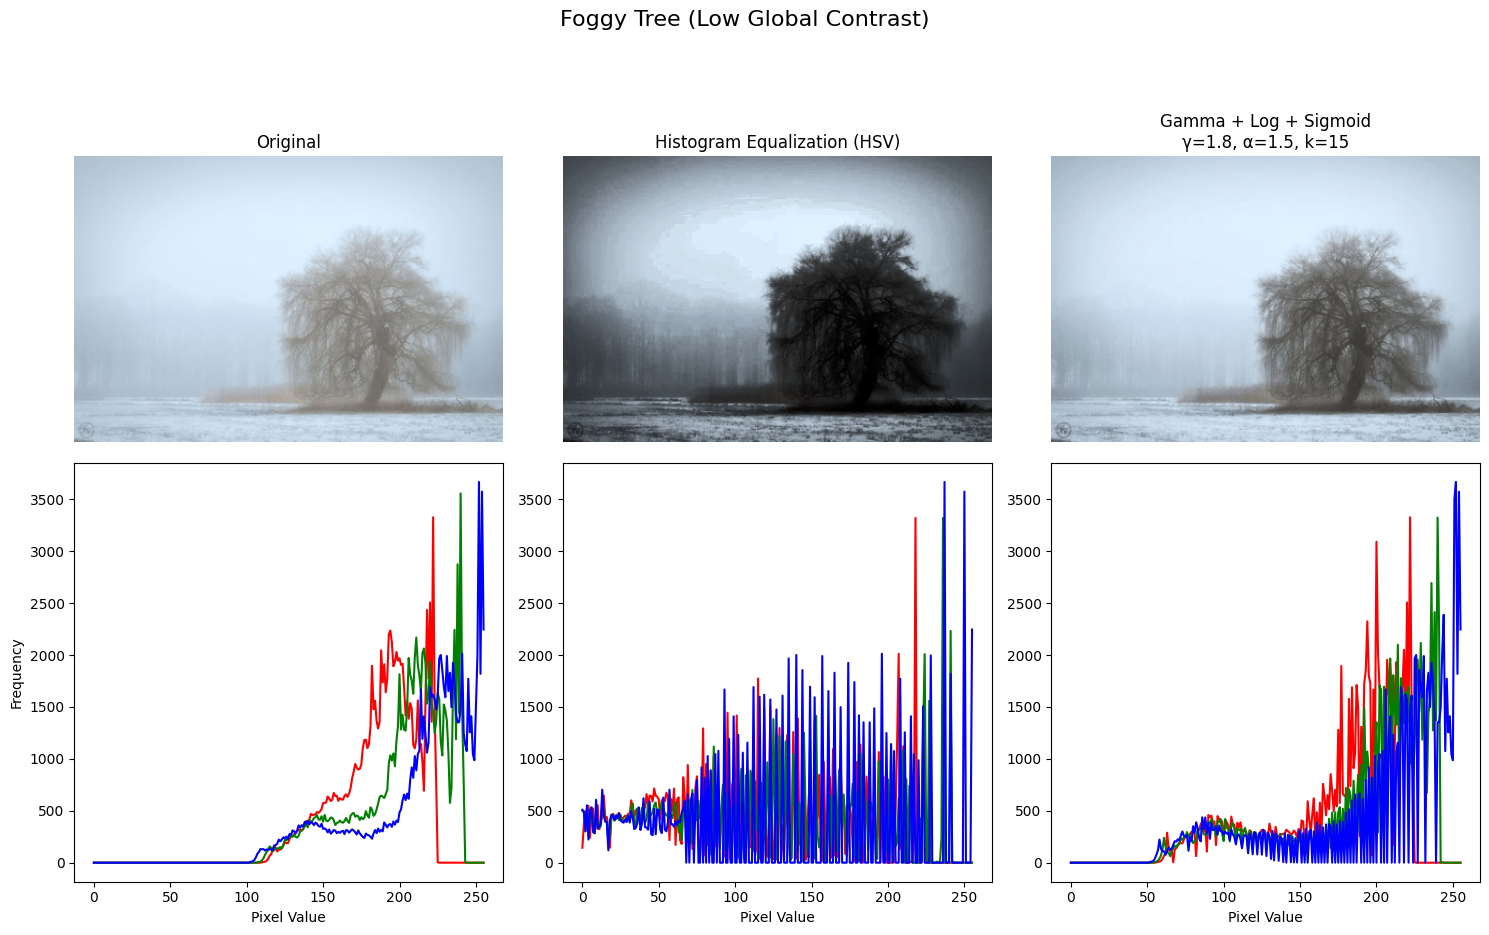

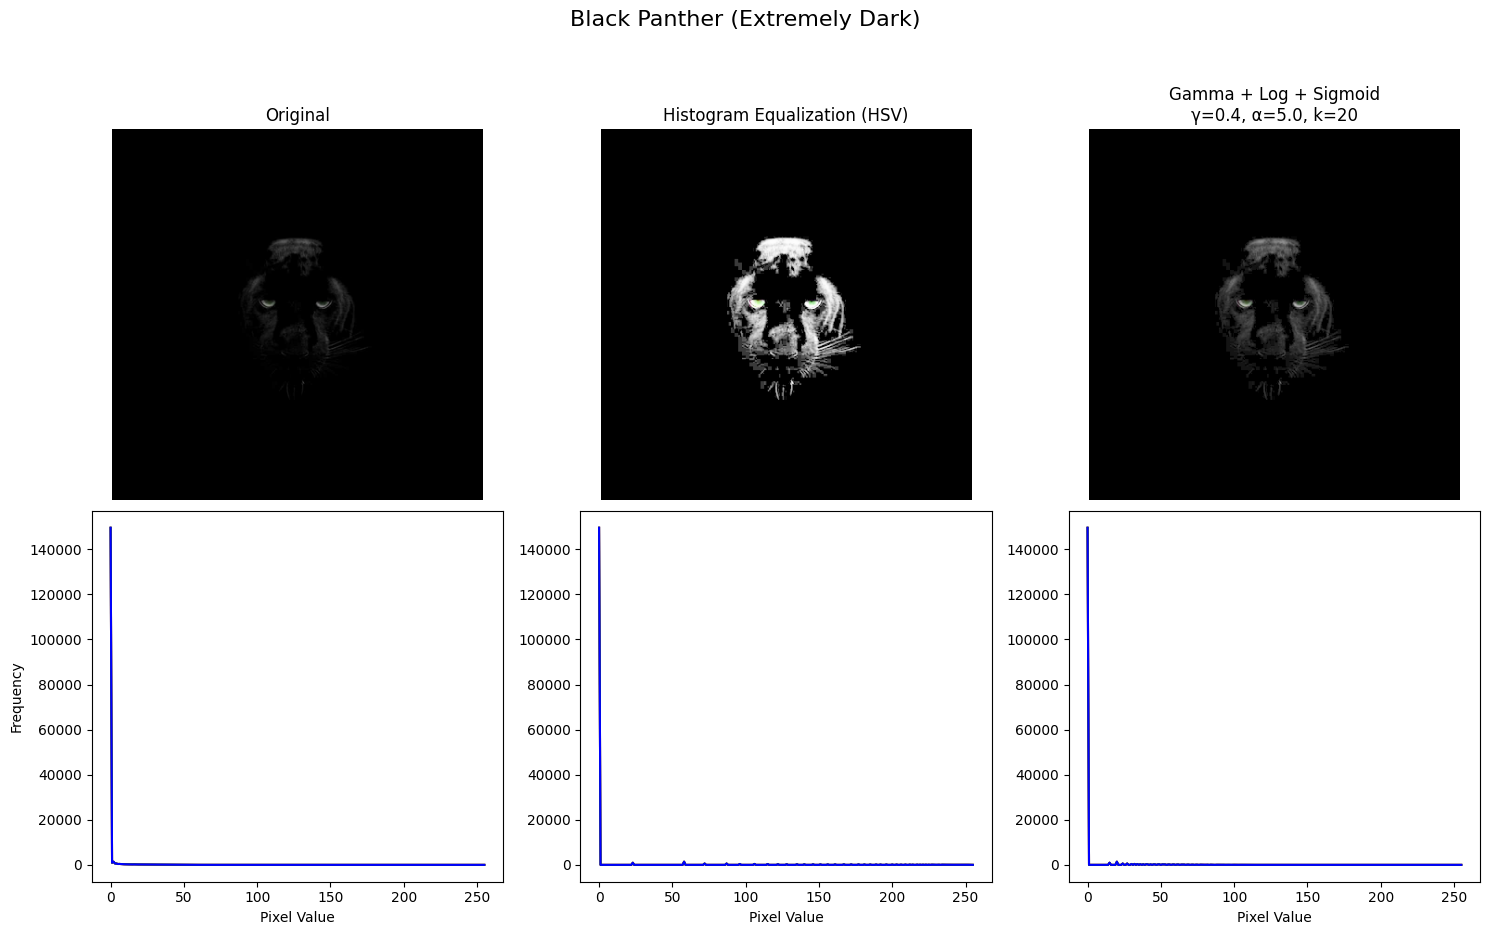

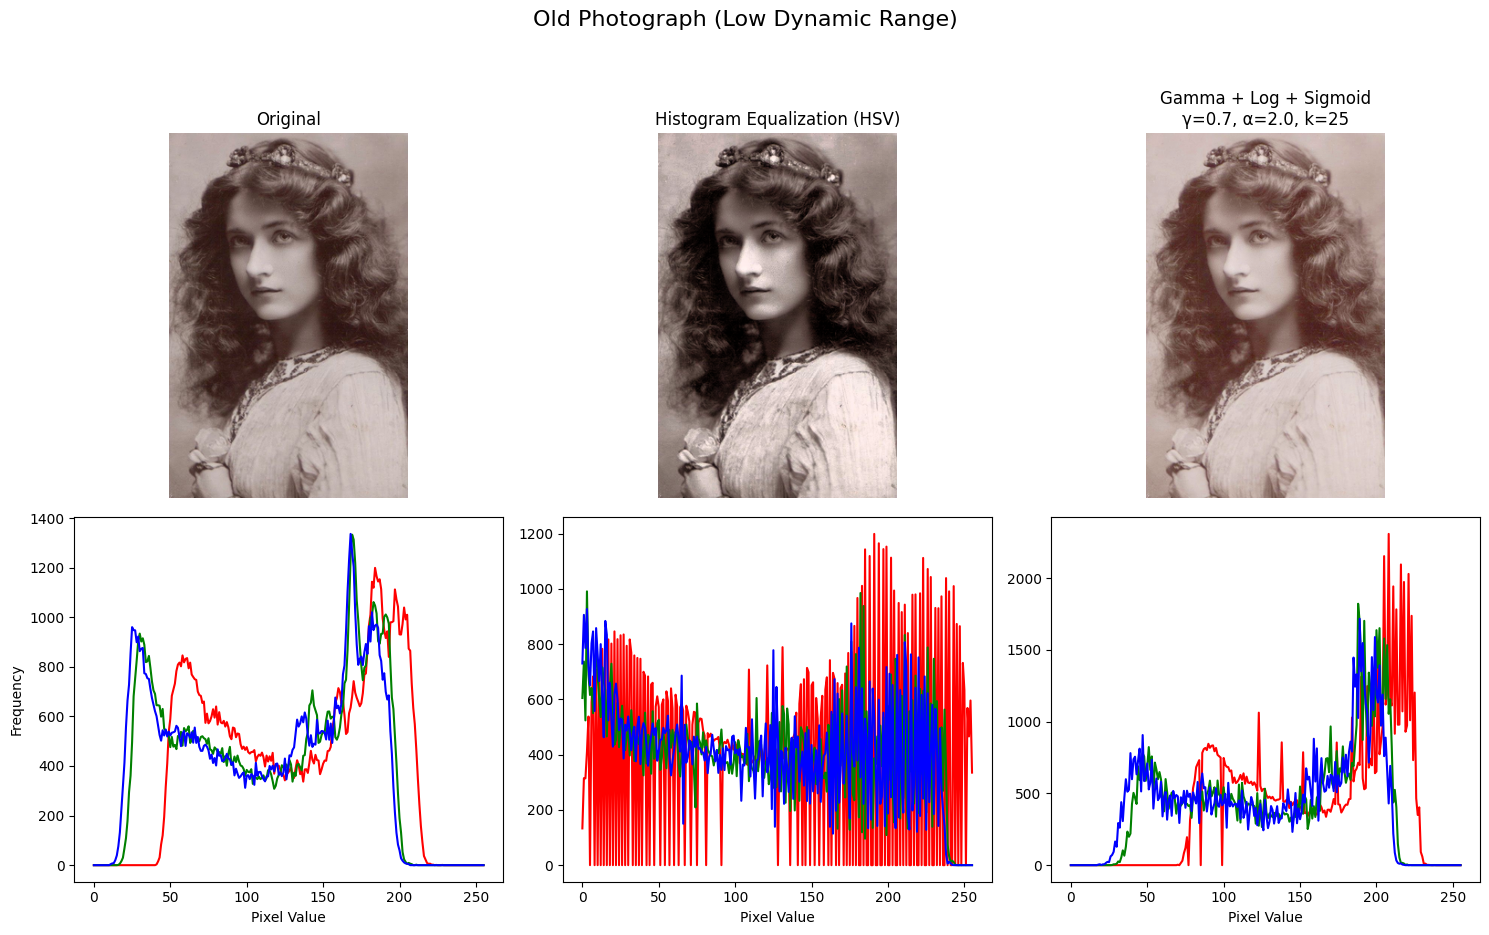

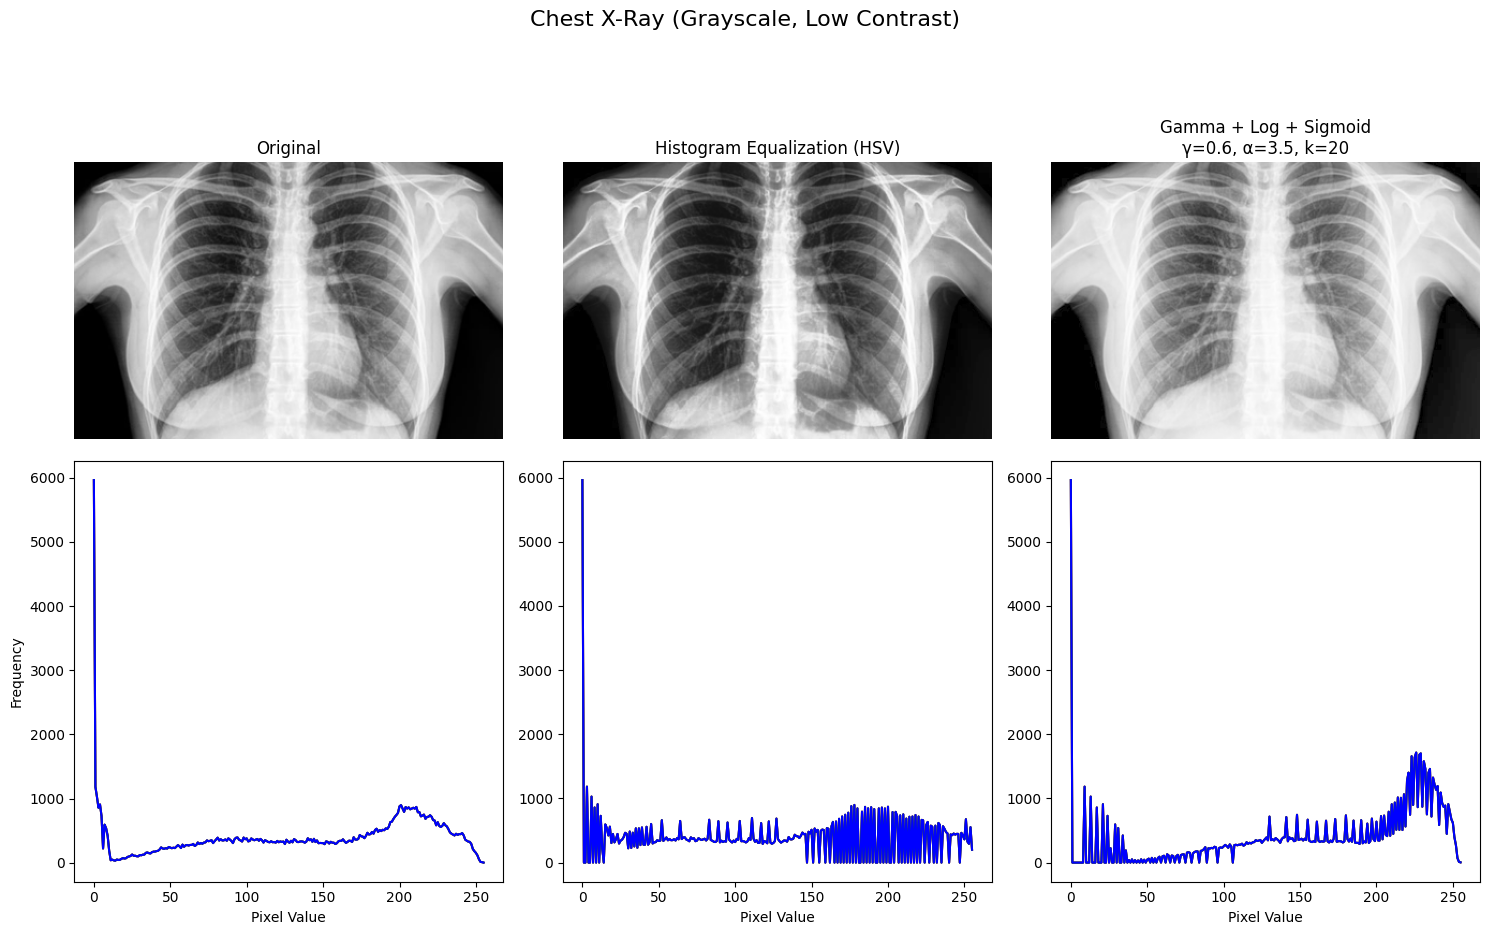

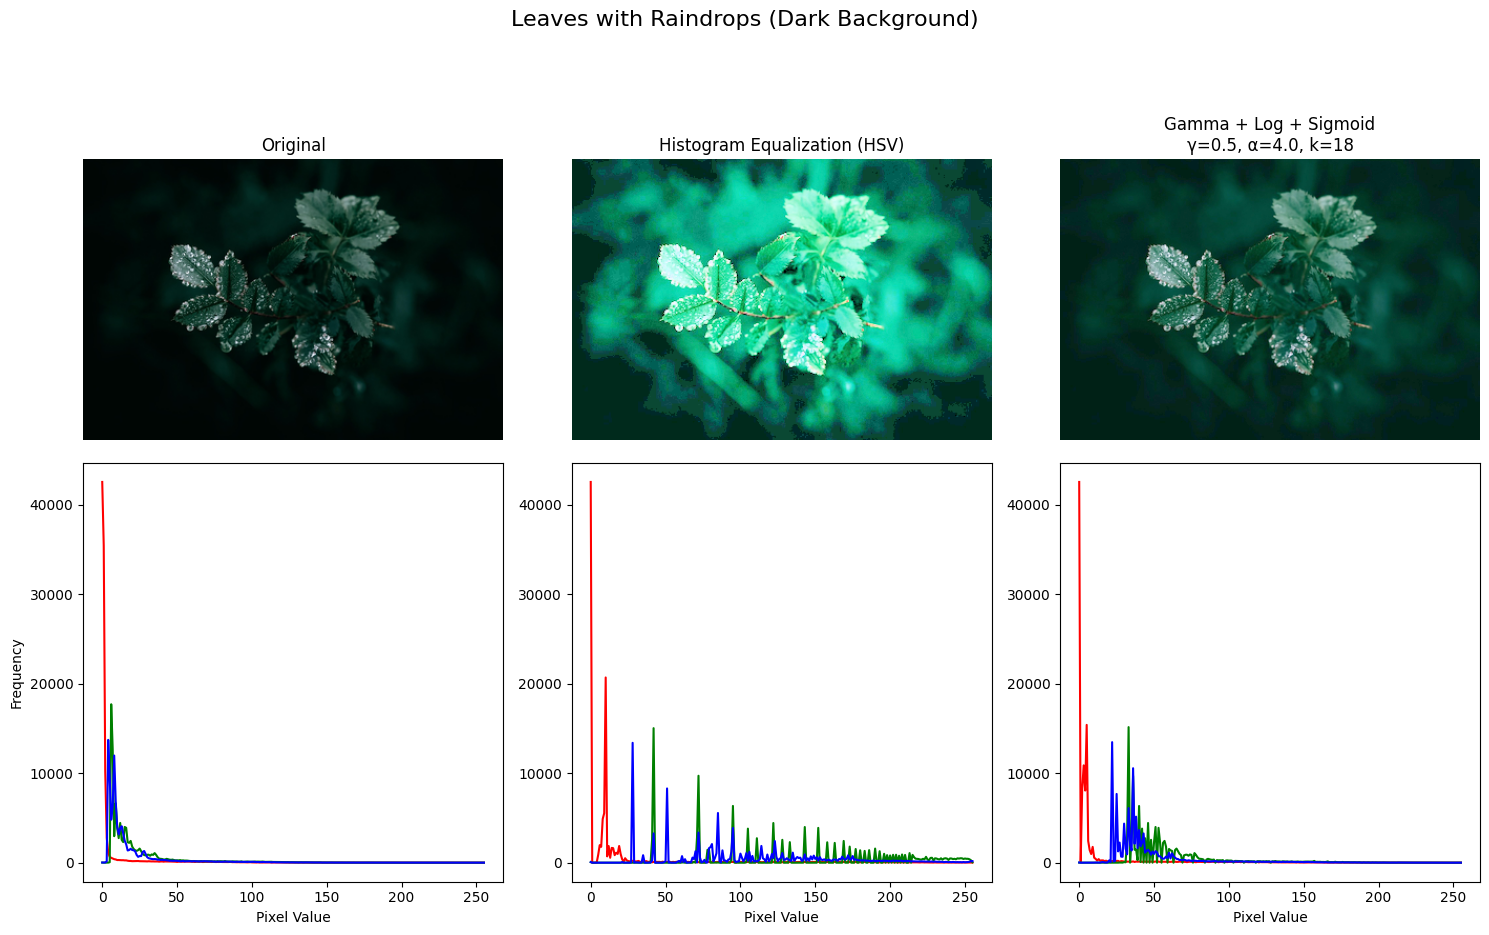

In [ ]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
import cv2


def load_image(url):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }
    response = requests.get(url, headers=headers)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    img.thumbnail((400, 400), Image.LANCZOS)
    return img


def pil_to_cv2(pil_img):
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)


def cv2_to_pil(cv2_img):
    return Image.fromarray(cv2.cvtColor(cv2_img, cv2.COLOR_BGR2RGB))


def histogram_equalization_hsv(image):
    img_cv = pil_to_cv2(image)
    img_hsv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2HSV)
    img_hsv[:, :, 2] = cv2.equalizeHist(img_hsv[:, :, 2])
    result = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2BGR)
    return cv2_to_pil(result)


def gamma_log_sigmoid_correction(image, gamma, alpha, k):
    img_cv = pil_to_cv2(image)
    img_hsv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2HSV).astype(np.float64)
    V = img_hsv[:, :, 2]

    I_n = V / 255.0
    T_n = np.mean(I_n)

    I_gamma = np.power(I_n, gamma)
    I_log = np.log1p(alpha * I_n) / np.log1p(alpha)
    w = 1.0 / (1.0 + np.exp(-k * (I_n - T_n)))

    I_out = (1.0 - w) * I_gamma + w * I_log

    img_hsv[:, :, 2] = np.clip(I_out * 255.0, 0, 255)
    result = cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    return cv2_to_pil(result)


def calculate_histogram(image):
    width, height = image.size
    pixels = image.load()

    r_hist = [0] * 256
    g_hist = [0] * 256
    b_hist = [0] * 256

    for x in range(width):
        for y in range(height):
            r, g, b = pixels[x, y]
            r_hist[r] += 1
            g_hist[g] += 1
            b_hist[b] += 1

    return r_hist, g_hist, b_hist


def plot_results(original, he_img, combined_img, gamma, alpha, k, title):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    images = [original, he_img, combined_img]
    titles = [
        "Original",
        "Histogram Equalization (HSV)",
        f"Gamma + Log + Sigmoid\nγ={gamma}, α={alpha}, k={k}"
    ]

    for i in range(3):
        axes[0, i].imshow(images[i])
        axes[0, i].set_title(titles[i])
        axes[0, i].axis("off")

        r_hist, g_hist, b_hist = calculate_histogram(images[i])
        axes[1, i].plot(r_hist, color="red")
        axes[1, i].plot(g_hist, color="green")
        axes[1, i].plot(b_hist, color="blue")
        axes[1, i].set_xlabel("Pixel Value")

        if i == 0:
            axes[1, i].set_ylabel("Frequency")

    plt.suptitle(title, fontsize=16)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


image_configs = [
    (
        "Foggy Tree (Low Global Contrast)",
        "https://petapixel.com/assets/uploads/2019/04/p2219651326-5-800x533.jpg",
        1.8, 1.5, 15,
    ),
    (
        "Black Panther (Extremely Dark)",
        "https://cdn.cssauthor.com/wp-content/uploads/2020/11/Collection-of-Excellent-Dark-Wallpapers.jpg?strip=all",
        0.4, 5.0, 20,
    ),
    (
        "Old Photograph (Low Dynamic Range)",
        "https://i.pinimg.com/736x/39/75/77/3975770cda0ee0969053f1cfa869ef44.jpg",
        0.7, 2.0, 25,
    ),
    (
        "Chest X-Ray (Grayscale, Low Contrast)",
        "https://www.bhf.org.uk/-/media/images/information-support/tests/chest-x-ray/normal-chest-x-ray-620x400.jpg?rev=d9cfde6ea0a249649d60284ae972f2da&la=en&h=400&w=620&hash=62E952C7382859AF3089F12EAC596D40",
        0.6, 3.5, 20,
    ),
    (
        "Leaves with Raindrops (Dark Background)",
        "https://cdn.pixabay.com/photo/2023/10/12/17/56/after-the-rain-8311416_1280.jpg",
        0.5, 4.0, 18,
    ),
]

for name, url, gamma_value, alpha_value, k_value in image_configs:
    img = load_image(url)
    he_img = histogram_equalization_hsv(img)
    combined_img = gamma_log_sigmoid_correction(img, gamma_value, alpha_value, k_value)

    plot_results(img, he_img, combined_img, gamma_value, alpha_value, k_value, name)

# **Secinājumi**
**1. Problemas apraksts**
Izvēlējos *kontrasta uzlabošanu*, kā savu attēlu apstrādes problēmu. Galvenais izaicinājums ir uzlabot redzamību un vienlaicīgi izcelt detaļas attēlos, kuriem ir zemas krāsu/toņu diapazonas, nezaudējot sākotnējo attēla informāciju. Standarta metodes, piemēram, parastā "histogrammas vienādošana" (Histogram Equalization), labāk izceļ attēla detaļas, bet ja attēlā ir pārāk daudz tumšo toņu, tad tas attēls neizskatās dabiski un ir pārāk spilgts.

---

**2. Izvēlētie algoritmi un metodes apraksts**
Lai risinātu šo kontrasta probēmu, es izvēlējos apvienot divus algoritmus: Gamma korekciju un Logaritmisko korekciju.

Izvēlējos šo kombināciju, jo gamma korekcija nav pietiekami efektīva ļoti tumšos attēlos, tāpēc es izvēlējos metodi, kurai padodas uzlabot tumšās detaļas attēlos. Pēc manām domām apvienojot šos abus algoritmus gala rezultāts iegūs plašākus un dabiskākus kontrasta uzlabojumus.

Apvienoju šos algoritmus ar "Sigmoīdas funkciju", padodot svara parametru (k), kas aprēķina attēla vidējo spilgtumu un izmanto sigmoīdu, lai noteiktu kādai vajadzētu būt pārejai, proti, tumšākajiem pikseļiem automātiski tiek vairāk padots logaritmiskais efekts, bet gaišākajiem gamma efekts.

---

**3. Rezultāti un to analīze**

  - 1. attēls - Miglainais koks

    - Histogrammas vienādošana padarīja miglā paslēptos kokuss redzamākus, kā arī zemes tekstūra ir saredzamāka, taču koka detaļas ir palikušas nesaprotamas. Fona detaļas ir palikušas skaidrākas, taču priekšplāna (priekšējā koka) detaļas ir palikušas sliktākas.

    - Šinī attēlā ir grūti saskatīt detaļas, jo krāsu diapazona ir ļoti maza, ko var secināt pēc histogrammas. Lai šīs detaļas padarītu redzamākas es nonācu pie gamma 1.8 vērtību, kas padarīja tumšākus apgabalus redzamākus. Alpha 1.5 vērtība padarīs tumšakus pixeļus redzamākus, bet tā kā šeit nav daudz ēnu vai tumšu toņu tad šī Alpha vērtība ir samērā maza. Un lai šos abus algoritmus apvienotu izvēlējos k 15 vērtību.
    
  - 2. attēls - Melnā pantera
      - Šis attēls ir ļoti tumš un vienīgo detaļu, kuru var saredzēt ir melnā pantera. Gala rezultāts no Histogrammas vienādošanu izskatās nedabīgs un pārāk spligts, ļoti grūti ir noteikt detaļas pie panteras acīm tās ir pazudušas.

      - Ar izvēlētājām algoritma vērtībām: 0.4, 5.0, 20 īpašu uzmanību pievērsu logaritmiskajam efektam, jo tas ir piemērotāks tumšākos scenārijos. Gala rezultāts iznāca dabīgs un nezaudēja oriģinālās bildes detaļas. Šis ir labs salīdzinājums, kāpēc šāda kontrasta uzlabošana ir nepieciešama.

  - 3. attēls - Veca fotografija
    - Histogrammas vienādošana šinī piemērā padarīja attēlu dabīgāku un padarīja krekla/džempera detaļas izteiktātkas. Šeit gala rezultāts izskatās labāk nekā kontrasta uzlabošanas algoritmam. Varētu šo iznākumu mainīt ar atkārtotu parametru mainīšanu, bet šeit var secināt ka pareizu parametru noteikšana ir mīnuss kontrasta uzlabošanas algoritmam.

    - Ar izvēlētajām algoritma vērtībām: 0.7, 2.0, 25 šīs vērtības iznākuma bildei iedeva sarkanu tintes efektu, proti, attēls palicis ir sarkanāks nekā iepriekš. Algoritma efektivitāte ir sliktāka, jo ir padoti nepareizi parametri, kas ir minuss šim algoritmam.

  - 4. attēls - Xrays
    - Histogrammas vienādošana šo attēlu padarīja skaidrāku, padarot gaišās krāsas izteiktākas ir vieglāk ieraudzīt skeleta struktūru. Taču aizmugurējo skeleta daļu ir grūtāk saprast, jo šie pelēkie toņi, kas pirmstam bija neizteikti palika vēl neizteiktāki.

    - Ar izvēlētajām algoritma vērtībām: 0.6, 3.5, 20 bildes tuvākie kauli (spilgtākie toņi) ir palikuši pārāk gaiši un sāk zaudēt detaļas, taču aizmugurējos kaulus tagad ir vieglāk saskatīt.

  - 5. attēls - Lapas ar lietuspilēm
    - Histogrammas vienādošana attēlu padarīja nedabīgu un pārāk spilgtu, ir pazaudētas daudzas detaļas, bet viss backgrounds  tagad ir labi saredzams.

    - Ar vērtībām: 0.5, 4.0, 18 šis attēls parāda kāpec šis algoritms ir labāks nekā Histogrammas vienādošana, tas atstāja visas attēla oriģinālās dētaļas, taču padarīaj to spilgtāku un backgroundu saredzamu.

---

**4. Kopējie secinājumi**
Veicot šo praktisko darbu secināju, ka vairāku algoritmu apvienošana sniedz ievērojami labākus rezultātus, nekā viena standarta algoritma izmantošana, piemēram, 1, 2. un 5. attēlā. Taču šīs metodes galvenais trūkums ir nepieciešamība noteikt parametrus, nepareizu parametru noteikšana var izbojāt attēlu, kā piemēram 3. attēlā. Savukārt Histogrammas vienādošana algoritms ne vienmēr ir sliktāks, piemēram, 3. un 4. attēlā. Galvenais ir prast noteikt kuram attēlam ir jāpiemēro kurš algoritms, jo nav neviens universāls algoritms, kas uzlabos kontrastu jebkurai bildei.

##*Papildus kods formatēta HTML faila iegūšanai*
Ar šo koda daļu ir iespējams saglabāt Colab Notebook kā HTML, kuru pēc tam var "izdrukāt" kā PDF, kopā ar visām izvadēm. Šī pieeja nodrošina labāku programmas koda un izvades attēlu renderēšanu, nekā mēgīnājumi to drukāt pa taisno no pārlūka.

In [ ]:
#Šo var palaist tad, ja Google Colab sūdzās, ka nav pieinstālēts nbconvert. Bet parasti tas NAV nepieciešams
!pip install nbconvert

In [ ]:
#Šis ir nepieciešams, lai dotu Google Colab pieeju diskam, kurā glabājās notebook fails, lai to pārkonvertētu uz HTML
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Šeit norādiet ceļu pie Jūsu Colab notebook faila, kur tieši tas atrodas var pābaudīt Google Drive. Ja šo veidni saglabājāt ar "Save a copy to Drive", tā visticamāk atrodas Colab Notebooks mapē.
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/Praktiskais darbs 6.ipynb" \
  --to html \
  --embed-images

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Praktiskais darbs 6.ipynb to html
[NbConvertApp] Writing 316936 bytes to /content/drive/MyDrive/Colab Notebooks/Praktiskais darbs 6.html


In [ ]:
#Notiek HTML faila lejuplāde
from google.colab import files
files.download("/content/drive/MyDrive/Colab Notebooks/Praktiskais darbs 6.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tālāk atverot lejuplādēto HTML failu pārlūkā, to var izdrukāt kā PDF (Save to PDF).